# Olympics Analysis from 1896 to 2016
### Spring 2026 Data Science Project
**Name:** Michael Brown

**Github Repository:** [Olympics Analysis](https://github.com/Michael-1898/OlympicsAnalysis_CMSC320)

### Contributions
**Michael Brown** Sole contributor. Developed the project concept, performed data curation and preprocessing on the Olympic dataset, conducted exploratory data analysis, and performed a machine learning analysis.

---

## Introduction
This tutorial provides a data-driven exploration of over 120 years of Olympic history, focusing on the "Modern Era" (1960–2016) where data is most consistent and physical standards are most specialized. Our objective is to determine if we can predict whether an athlete will win a medal based solely on four primary attributes: Age, Height, Weight, and Sport.

Throughout this pipeline, we will:
- **Curate and Process:** Filter historical records to ensure modern relevance and engineer interaction features to capture the nuances of sex-specific sport requirements.
- **Explore:** Use statistical hypothesis testing and visualization to inform our machine learning analysis.
- **Model:** Implement a Random Forest Classifier to navigate the non-linear relationship between an physical traits and success in different sports.
- **Analyze:** See how the influence of physical traits shifts between different sporting disciplines.

---

### Library Imports
*The following libraries are used throughout this tutorial

In [104]:
# General
import pandas as pd
import numpy as np
import string

# EDA
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Visualization
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

---

## Dataset Curation and Preprocessing
#### Dataset Breakdown
This section walks through the process of transforming a raw dataset into a clean, structured format ready for machine learning. This involves filtering out historical noise, handling missing values, and engineering new features that better capture the relationship between an athlete's physical profile and their success.

The primary dataset for this analysis is the 120 years of Olympic history: athletes and results, which can be found on Kaggle. This dataset contains 271,116 rows and 15 columns, tracking every athlete who participated in the Olympic Games from Athens 1896 to Rio 2016.

#### Loading the Data

In [114]:
# Load the datasets
olympics_df = pd.read_csv('athlete_events.csv')
noc_regions_df = pd.read_csv('noc_regions.csv')

# Merge with regions to have country names associated with National Olympic Committees (NOC)
olympics_df = pd.merge(olympics_df, noc_regions_df, on='NOC', how='left')

# Display the first few rows
olympics_df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,Netherlands,NaN


#### Filtering to the Modern Era
One of the most important steps in this pipeline is narrowing the scope. Large amounts of physiological data for the early years of the Olympics (1896–1950s), like height and weight is missing. Furthermore, the level of professionalization and specialized training was different than it is today. Machine learning models are only as good as the data provided to them. So to ensure our model is accurate and relevant we filter the dataset to include only the years from 1965 onward.

In [115]:
# Filter for the modern era to ensure better data quality and relevance
modern_olympics = olympics_df[olympics_df['Year'] >= 1965].copy()

# Check for missing values in our key physical attributes
print(modern_olympics[['Height', 'Weight', 'Age']].isnull().sum())
print(f"Remaining rows: {modern_olympics.shape[0]}")

Height     9477
Weight    10068
Age         838
dtype: int64
Remaining rows: 190357


#### Handling Missing Data and Medal Column
As you can seen, even with filtering to the "modern era", some athletes still have missing physioligical data. Since our dataset is still so large we will remove rows where this information is unavailable, as it won't have too large of an impact overall. We also need to transform the Medal column into a binary target variable: Won_Medal. After this, the proportion of medalists should be much smaller than the proportion of non-medlaists.

In [116]:
# Drop rows where critical physical data is missing
modern_olympics.dropna(subset=['Height', 'Weight', 'Age'], inplace=True)

# Create a binary target variable: 1 if any medal was won, 0 otherwise
modern_olympics['Won_Medal'] = modern_olympics['Medal'].notnull().astype(int)

# Verify the class balance
print(modern_olympics['Won_Medal'].value_counts(normalize=True))

Won_Medal
0    0.857328
1    0.142672
Name: proportion, dtype: float64


#### Feature Engineering: Sport Clustering
There are over 60 different sports in the dataset. But many of these sports look for similar physical characterisitics. So we can group sports with similar physical demands into "clusters." This helps the model identify broader patterns (e.g., "Combat Sports" vs. "Endurance Sports"). This does limit the analysis to some degree by generalizing results to multiple sports, but it makes the analysis easier to visualize and understand. Performing the same analysis without clustering here could provide more specific results.

We also create a combined sport/sex feature since the physical requirments can vary by sex, even within a sport (such as gymnastics).

In [117]:
# Define a mapping for sport categories
sport_map = {
    'Basketball': 'Team_Ball', 'Volleyball': 'Team_Ball', 'Football': 'Team_Ball',
    'Wrestling': 'Combat', 'Judo': 'Combat', 'Boxing': 'Combat',
    'Swimming': 'Water_Power', 'Water Polo': 'Water_Power',
    'Gymnastics': 'Aesthetic_Tech', 'Diving': 'Aesthetic_Tech',
    'Athletics': 'Track_Field', 'Weightlifting': 'Power_Strength'
}

# Apply the mapping and fill others as 'Other'
modern_olympics['Sport_Category'] = modern_olympics['Sport'].map(sport_map).fillna('Other')

# Create a combined 'Sport_Sex' feature to capture sex-based physical requirements
modern_olympics['Sport_Sex'] = modern_olympics['Sport_Category'] + "_" + modern_olympics['Sex']

#### Final Data Preparation
Lastly, we drop columns that won't be used in the model (like Name, ID, or specific Games) and convert categorical variables into a format the computer can process.

In [118]:
# Selecting columns for the final analysis
features = ['Age', 'Height', 'Weight']
target = 'Won_Medal'
group = 'Sport_Sex'

# Quick dataset overview
print("Total rows:", len(modern_olympics))
print("Number of Sport_Sex categories:",
      modern_olympics[group].nunique())

print("\nCategories:")
print(sorted(modern_olympics[group].unique()))

Total rows: 179335
Number of Sport_Sex categories: 14

Categories:
['Aesthetic_Tech_F', 'Aesthetic_Tech_M', 'Combat_F', 'Combat_M', 'Other_F', 'Other_M', 'Power_Strength_F', 'Power_Strength_M', 'Team_Ball_F', 'Team_Ball_M', 'Track_Field_F', 'Track_Field_M', 'Water_Power_F', 'Water_Power_M']


---

## Exploratory Data Analysis (EDA)
Before starting our machine learning analysis, we'll perform some exploratory data analysis to identify patterns and justify specific features we will use in our predictive modeling.

#### Summary Statistics
Note the class imbalance for the Won_Medal feature. We'll have to consider this when evaluating our future model as predicting "no medal" everytime would still yield a high performance

In [119]:
# Displaying basic summary statistics for physical traits
print("Summary Statistics for Modern Olympians (1960-2016):")
display(modern_olympics[['Age', 'Height', 'Weight']].describe())

# Checking the target variable distribution
medal_counts = modern_olympics['Won_Medal'].value_counts(normalize=True) * 100
print(f"\nMedal Distribution:\n{medal_counts.map('{:.2f}%'.format)}")

Summary Statistics for Modern Olympians (1960-2016):


,Age,Height,Weight
count,179335.000000,179335.000000,179335.000000
mean,25.052700,175.573257,70.774110
std,5.450449,10.714303,14.660213
min,11.000000,127.000000,25.000000
25%,21.000000,168.000000,60.000000
50%,24.000000,175.000000,70.000000
75%,28.000000,183.000000,80.000000
max,71.000000,226.000000,214.000000



Medal Distribution:
Won_Medal
0    85.73%
1    14.27%
Name: proportion, dtype: object


#### Hypothesis Test: Does Age Drive Success?
Here we use a Welch's t-test to to determine if age is a meaningful predictor of success. We specifically use a Welch's t-test because it does not assume equal variance, as there is a large imbalance between medal vs. no medal.

**Question:** Do medalists differ physically from non-medalists?

**Null Hypothesis:** There is no difference in the mean age between athletes who did and did not win a medal.

**Alternative Hypothesis:** There is a difference in the mean age between athletes who did and did not win a medal

**Signifigance Level:** 0.01

In [111]:
# Splitting the data into medalists and non-medalists
medalists = modern_olympics[modern_olympics['Won_Medal'] == 1]['Age']
non_medalists = modern_olympics[modern_olympics['Won_Medal'] == 0]['Age']

# Welch's t-test
t_stat, p_val = ttest_ind(medalists, non_medalists, equal_var=False)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_val}")

T-statistic: 14.9513904200285
P-value: 2.1477611608787705e-50


**Interpretation:** The extremely low p-value ($2.15 \times 10^{-50}$) allows us to reject the null hypothesis with high confidence, supporting the conclusion that there is a statistically significant difference in the mean age of medalists compared to non-medalists. This result confirms that age is a statistically relevant predictor and subsequently should be a feature in our machine learning model to help distinguish successful athletes.

#### Correlation Analysis
Next, we look at how strongly each physical trait correlates with winning a medal. A correlation heatmap helps to visualize whether any single attribute (such as being exceptionally tall) is a strong sign for Olympic success.

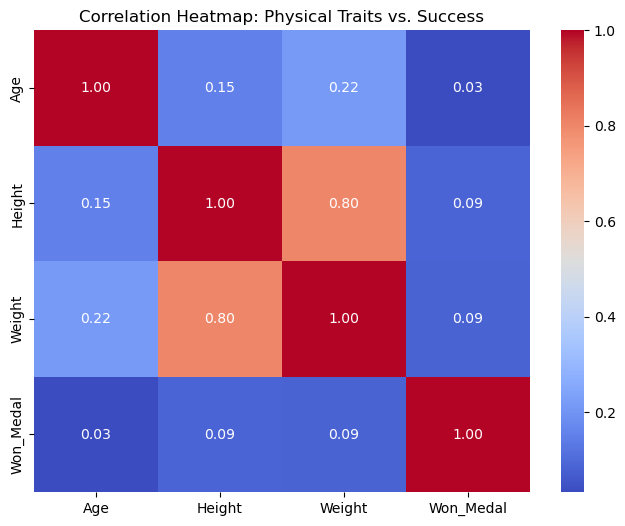

In [112]:
# Correlation matrix
corr_matrix = modern_olympics[['Age', 'Height', 'Weight', 'Won_Medal']].corr()

# Plotting the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: Physical Traits vs. Success')
plt.show()

**Interpretation:** The heatmap reveals very weak linear correlations between individual physical traits and winning a medal, with coefficients ranging from 0.03 for age to 0.09 for height and weight. These findings suggest that no single physical characteristic serves as a perfect predictor for Olympic success across all disciplines. Additionally, this lack of a linear signal justifies us using a more complex machine learning technique, such as a random forest, which can capture the non-linear interactions between these variables.

#### Visualization of Sport Context
The low global correlation found above occurs because the "ideal" body type changes drastically depending on the sport. To visualize this, we can look at the distribution of height across several distinct sport categories.

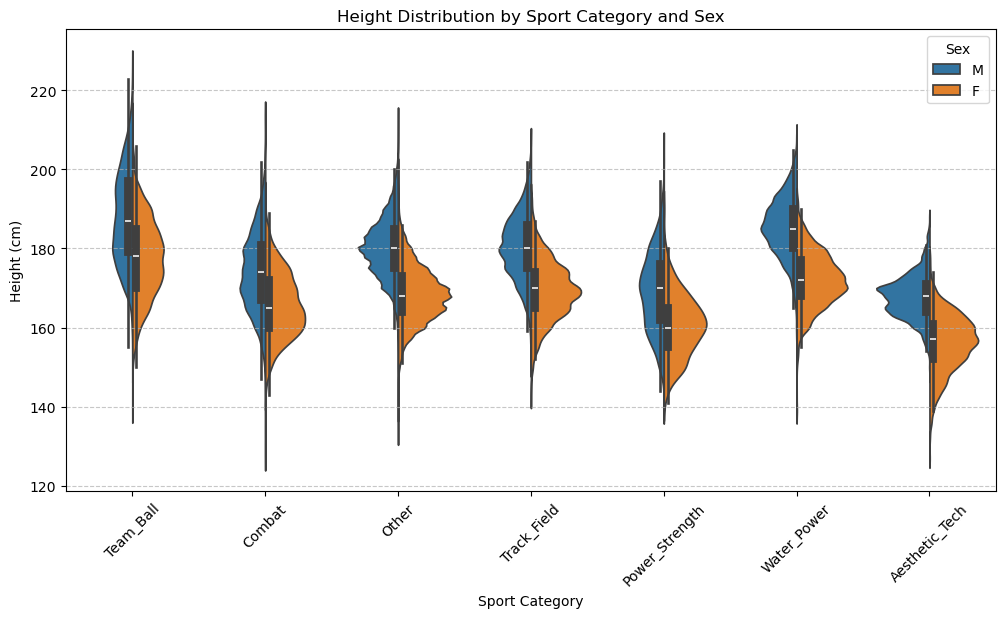

In [113]:
# Plot of height distributions by sport
plt.figure(figsize=(12, 6))
sns.violinplot(data=modern_olympics, x='Sport_Category', y='Height', hue='Sex', split=True)

plt.title('Height Distribution by Sport Category and Sex')
plt.xlabel('Sport Category')
plt.ylabel('Height (cm)')
plt.xticks(rotation=45)
plt.legend(title='Sex', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Interpretation:** This visualization demonstrates that ideal physical archetypes are highly dependent on the specific sport. For example, athletes in Team_Ball are significantly taller on average than those in Aesthetic_Tech. Additionally, heigh differs not just by sport, but by sex within those sports. The distinct, non-overlapping distributions prove that physical data cannot be interpreted in a vacuum. This is exaclty why created Sport_Sex. It allows us to create a model for each sport/sex category and evaluate an athlete's height and weight within the context of their specific event.

---

## Primary Analysis
#### Machine Learning Model Design
Our goal is to estimate the probability that an athlete wins a medal within a specific Sport_Sex category based on their physical profile (Age, Height, Weight).

From our EDA, there are two notable things:
- The relationship between physical traits and success is weak when viewed globally
- Physical traits vary much more meaningfully when conditioned on sport type and sex

Because of this, we train separate binary classification models for each Sport_Sex category rather than one global model. 

A **Random Forest Classifier** a good fit for this problem as it can capture the non-linear relationships between physical traits and medal succes and it works well with imbalanced data.

#### Machine Learning Model Training
For the training step, we loop through each Sport_Sex category and build a separate model using only athletes in that group. For each category, we use Age, Height, and Weight as inputs and Won_Medal as the target.

We split each category’s data into training and test sets using a typical 80/20 split with stratification so the medal/non-medal balance is preserved as much as possible. Then we train a Random Forest model for that category and record its performance using **accuracy** and **ROC-AUC**. ROC-AUC evaluates how well a model separates medalists from non-medalists. ROC plots **recall** on the y-axis and false-positive rate on the x-axis. AUC compresses the curve into one number representing the probability that the model ranks a random medalist higher than a random non-medalist. Higher ROC-AUC values indicate stronger separation between the two groups and therefore stronger predictive signal in the physical profile traits.

Categories with too few rows or only one class are skipped because they do not provide enough information for a reliable model.

In [92]:
# Store trained models
models = {}

# Store evaluation results
results = []

# Store detailed reports
classification_reports = {}

# Minimum rows required for a category
MIN_ROWS = 100

# Loop through each Sport_Sex category
for category, df_cat in modern_olympics.groupby(group):
    print("=" * 60)
    print(f"Processing category: {category}")

    df_cat = df_cat.copy()

    # Skip very small datasets
    if len(df_cat) < MIN_ROWS:
        print(f"Skipped: fewer than {MIN_ROWS} rows")
        continue

    # Features and target
    X = df_cat[features]
    y = df_cat[target]

    # Skip if only one class exists
    if y.nunique() < 2:
        print("Skipped: only one class present")
        continue

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # Create model
    model = RandomForestClassifier(
        n_estimators=100, # 100 trees creates a nice diversity to reduce error without taking too long to compute
        class_weight='balanced', # Set class_weight to 'balanced' to account for the class imbalance in Won_Medal
        random_state=42
    )

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities for ROC-AUC
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = (y_pred == y_test).mean()

    try:
        auc = roc_auc_score(y_test, y_prob)
    except:
        auc = np.nan

    # Save results
    results.append({
        'Sport_Sex': category,
        'Rows': len(df_cat),
        'Medal_Rate': y.mean(),
        'Accuracy': accuracy,
        'ROC_AUC': auc
    })

    # Save model and classification report
    models[category] = model
    classification_reports[category] = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )

    # Uncomment to print results as they are processed (or wait to see full results from next code block)
    # print(f"Rows: {len(df_cat)}")
    # print(f"Medal rate: {y.mean():.3f}")
    # print(f"Accuracy: {accuracy:.3f}")
    # print(f"ROC-AUC: {auc:.3f}")

Processing category: Aesthetic_Tech_F
Processing category: Aesthetic_Tech_M
Processing category: Combat_F
Processing category: Combat_M
Processing category: Other_F
Processing category: Other_M
Processing category: Power_Strength_F
Processing category: Power_Strength_M
Processing category: Team_Ball_F
Processing category: Team_Ball_M
Processing category: Track_Field_F
Processing category: Track_Field_M
Processing category: Water_Power_F
Processing category: Water_Power_M


Now we can display our full results

In [91]:
results_df = pd.DataFrame(results)

# Sort by ROC-AUC
results_df = results_df.sort_values(
    by='ROC_AUC',
    ascending=False
)
print(results_df)
display(results_df)

           Sport_Sex   Rows  Medal_Rate  Accuracy   ROC_AUC
12     Water_Power_F   8368    0.148184  0.813620  0.767728
13     Water_Power_M  11215    0.141329  0.799822  0.750355
1   Aesthetic_Tech_M   9160    0.070633  0.828603  0.730387
0   Aesthetic_Tech_F   6857    0.079043  0.837464  0.700224
10     Track_Field_F   9764    0.102622  0.844854  0.612487
6   Power_Strength_F    460    0.228261  0.717391  0.602280
5            Other_M  63126    0.141954  0.725408  0.584082
4            Other_F  31838    0.169389  0.705716  0.579386
9        Team_Ball_M   6437    0.242038  0.673137  0.574082
11     Track_Field_M  14997    0.081083  0.848667  0.573913
3           Combat_M  10034    0.159558  0.754360  0.532406
7   Power_Strength_M   2102    0.157469  0.800475  0.517819
8        Team_Ball_F   3618    0.311222  0.610497  0.511917
2           Combat_F   1359    0.205298  0.750000  0.505084


,Sport_Sex,Rows,Medal_Rate,Accuracy,ROC_AUC
12,Water_Power_F,8368,0.148184,0.813620,0.767728
13,Water_Power_M,11215,0.141329,0.799822,0.750355
1,Aesthetic_Tech_M,9160,0.070633,0.828603,0.730387
0,Aesthetic_Tech_F,6857,0.079043,0.837464,0.700224
10,Track_Field_F,9764,0.102622,0.844854,0.612487
6,Power_Strength_F,460,0.228261,0.717391,0.602280
5,Other_M,63126,0.141954,0.725408,0.584082
4,Other_F,31838,0.169389,0.705716,0.579386
9,Team_Ball_M,6437,0.242038,0.673137,0.574082
11,Track_Field_M,14997,0.081083,0.848667,0.573913


#### Test Data Analysis
The test results show that performance varies across Sport_Sex categories. Some categories are more learnable from physical profile alone, while others remain difficult because medal success depends heavily on training quality, skill, strategy, or other factors not captured in the dataset. Categories such as Water_Power_F, Water_Power_M, and the Aesthetic_Tech groups achieved the highest ROC-AUC scores, suggesting that physical characteristics like height, weight, and age are more strongly associated with medal success in those sports. Notably those sports tend to be more associated with strict biomechanical and physiological requirements. In contrast, categories such as Combat, Team_Ball, and some Power_Strength groups produced ROC-AUC values near 0.5, indicating that physical profile alone provides little separation between medalists and non-medalists in these sports. This could be explained by weight classes in Combat sports, although these results are surprising for the Team_Ball and Power_Strength groups as baseketball is associated with height, and strength sports are associated with higher weights. Spltting these groups further into the exact different sports may provide more insight. Generally, groups with lower ROC-AUC values should be more dependent on on factors such as strategy, technical skill, teamwork, or weight-class structures according to this analysis.

Because the models are trained separately by category, the most useful comparisons are the per-category metrics rather than a single overall score. Accuracy could be high simply because most athletes are not medalists, but ROC-AUC measures how well each model ranks medalists above non-medalists, even when the classes are imbalanced.

Overall, the results support the conclusion that physical traits contain meaningful predictive signal, but that the strength of this signal is highly dependent on sport-specific context rather than being universal across all Olympic events.

---

## Visualization and Result Analysis
Now that we have trained and tested our model, we can try to better understand and visualize our results.

#### Performance by Category
The ROC-AUC scores vary considerably across different categories, indicating that physical traits are more predictive in some sport-sex groups than others. Categories with higher ROC-AUC values imply stronger relationships between physical traits and medal success, while lower-performing categories may depend more heavily on technical skill, strategy, training, or other unmeasured factors.

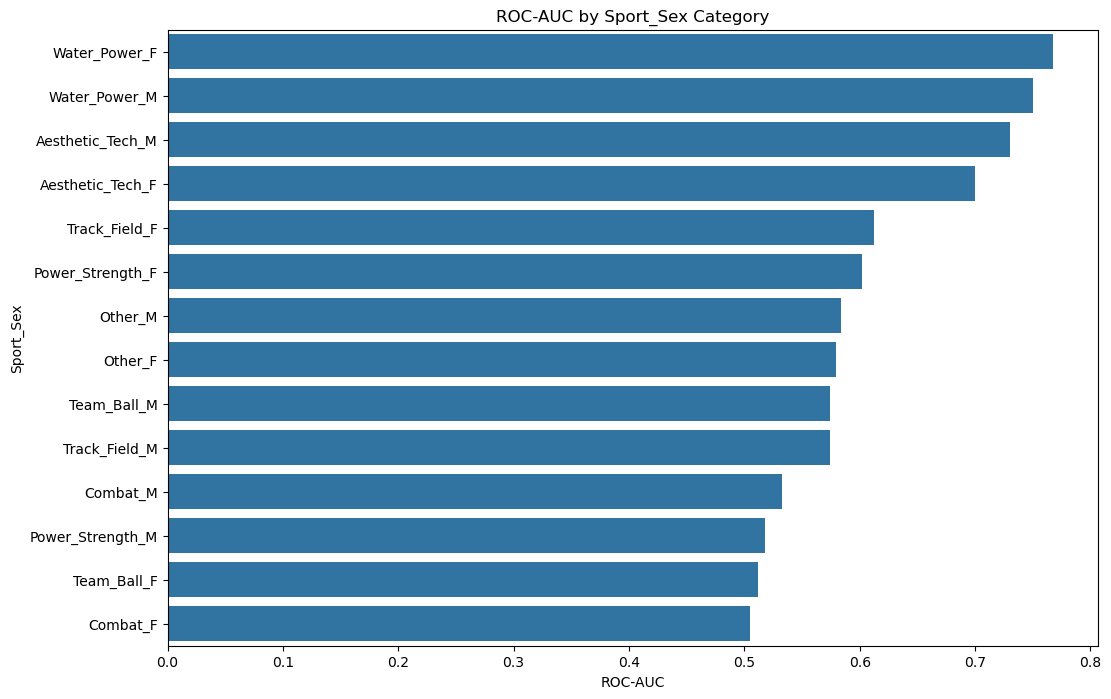

In [93]:
plt.figure(figsize=(12,8))
sns.barplot(
    data=results_df,
    x='ROC_AUC',
    y='Sport_Sex'
)

plt.title("ROC-AUC by Sport_Sex Category")
plt.xlabel("ROC-AUC")
plt.ylabel("Sport_Sex")
plt.show()

#### Feature Importance
Random Forest lets us look at which features were most important. Different physical characteristics contribute differently across sport-sex categories. In some categories, weight is the dominant predictor, while in others height or age contributes more strongly. This supports the earlier hypothesis that ideal physiological profiles vary substantially across Olympic sports. We can look at the average across all sport-sex categories which shows that weight has the highest importance on average.

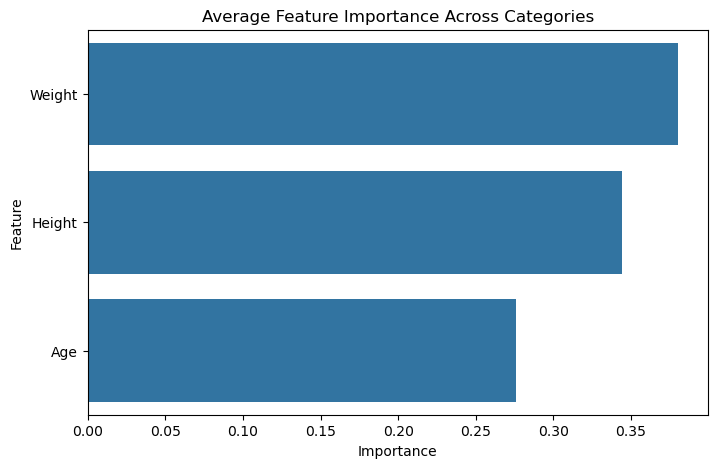

In [84]:
# Average feature importance across categories
avg_importance = (
    importance_df
    .groupby('Feature')['Importance']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
sns.barplot(
    x=avg_importance.values,
    y=avg_importance.index
)

plt.title("Average Feature Importance Across Categories")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

**Feature importance for a specific feature:** Enter target feature into "selected_category" variable to see distribution.

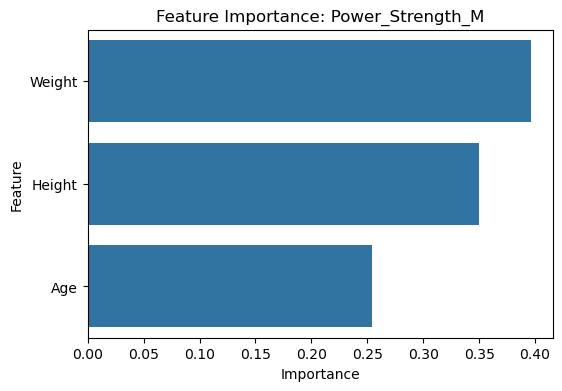

In [98]:
selected_category = "Power_Strength_M"
model = models[selected_category]

importance_df_single = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})
importance_df_single = importance_df_single.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(6,4))
sns.barplot(
    data=importance_df_single,
    x='Importance',
    y='Feature'
)
plt.title(f"Feature Importance: {selected_category}")
plt.show()

#### Example Athlete Predictions
Now we can use our different trained models to predict how an athelete may perform in different olympic sport-sex categories. Taller and heavier athlete profiles might receive higher probabilities in power and size oriented categories, while smaller/lighter profiles align more strongly with categories emphasizing agility or lower body mass.

In [99]:
def predict_medal_probabilities(age, height, weight):
    athlete_df = pd.DataFrame([{
        'Age': age,
        'Height': height,
        'Weight': weight
    }])

    probabilities = {}
    for category, model in models.items():
        prob = model.predict_proba(athlete_df)[0][1]
        probabilities[category] = prob

    prob_df = pd.DataFrame({
        'Sport_Sex': probabilities.keys(),
        'Medal_Probability': probabilities.values()
    })

    prob_df = prob_df.sort_values(
        by='Medal_Probability',
        ascending=False
    )

    return prob_df

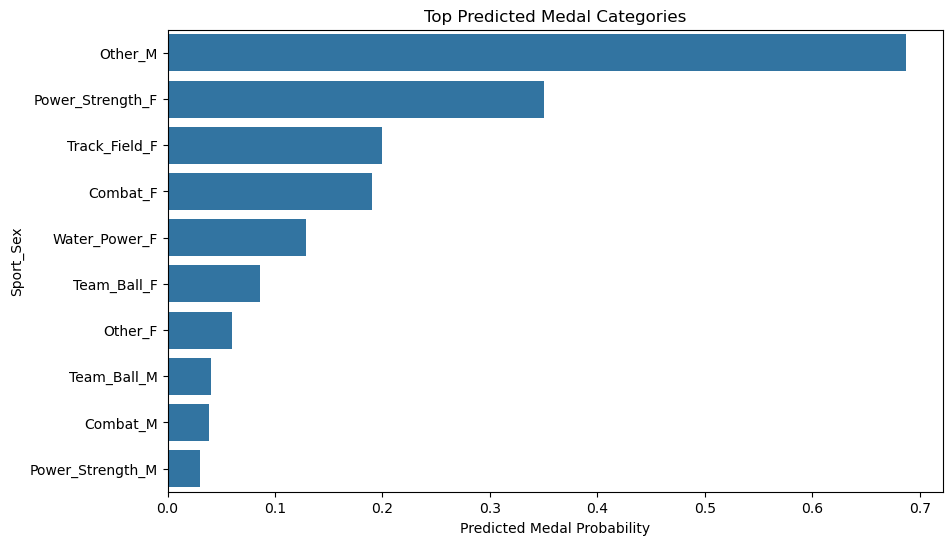

In [102]:
example_prediction = predict_medal_probabilities(
    age=24,
    height=190, # Roughly 6 foot 3 inches
    weight=85 # Roughly 187lbs
)

top_n = 10
top_predictions = example_prediction.head(top_n)

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_predictions,
    x='Medal_Probability',
    y='Sport_Sex'
)

plt.title("Top Predicted Medal Categories")
plt.xlabel("Predicted Medal Probability")
plt.ylabel("Sport_Sex")
plt.show()

---

## Conclusion
In this project, Olympic athlete data from the modern era was analyzed to investigate how physical characteristics relate to medal success across different sport-sex categories. Exploratory analysis showed that global relationships between variables such as age, height, and weight and medal outcomes were relatively weak, suggesting that the influence of physical traits depends heavily on sport-specific context. To address this, separate machine learning models were trained for each Sport_Sex category rather than using a single global model. The results demonstrated substantial variation in predictive performance across categories, with some groups showing strong physiological patterns and others remaining difficult to predict from physical profile alone. Overall, the findings suggest that physical traits do contain meaningful predictive information, but their importance varies significantly depending on the biomechanical and strategic demands of each sport.